# [Hands-On] Activation Function Exploration: ReLU vs. Swish
- Author : Sangkeun Jung (hugmanskj@gmail.com)

> Educational Purpose

**Copyright**: All rights reserved

---

In this notebook, we will dive into various activation functions used in neural networks, with a particular focus on comparing ReLU and Swish. Through visualizations and experiments, we will explore their characteristics, impact on neuron activations, and gradient flow behavior. This will help us understand how Swish addresses some of the limitations of ReLU, such as dead neurons.






 ## Objectives
 - Understand the characteristics of various activation functions.
 - Compare the ReLU and Swish activation functions.
 - Investigate the phenomenon of dead neurons, particularly with ReLU.
 - Experimentally observe how the gradient flow differs between ReLU and Swish and how Swish reduces the likelihood of neurons getting stuck at zero.

## Activation Functions Overview

Below is a visual comparison of different activation functions including ReLU, Swish, Sigmoid, Tanh, Leaky ReLU, and GELU. These functions play a critical role in introducing non-linearity to neural networks.



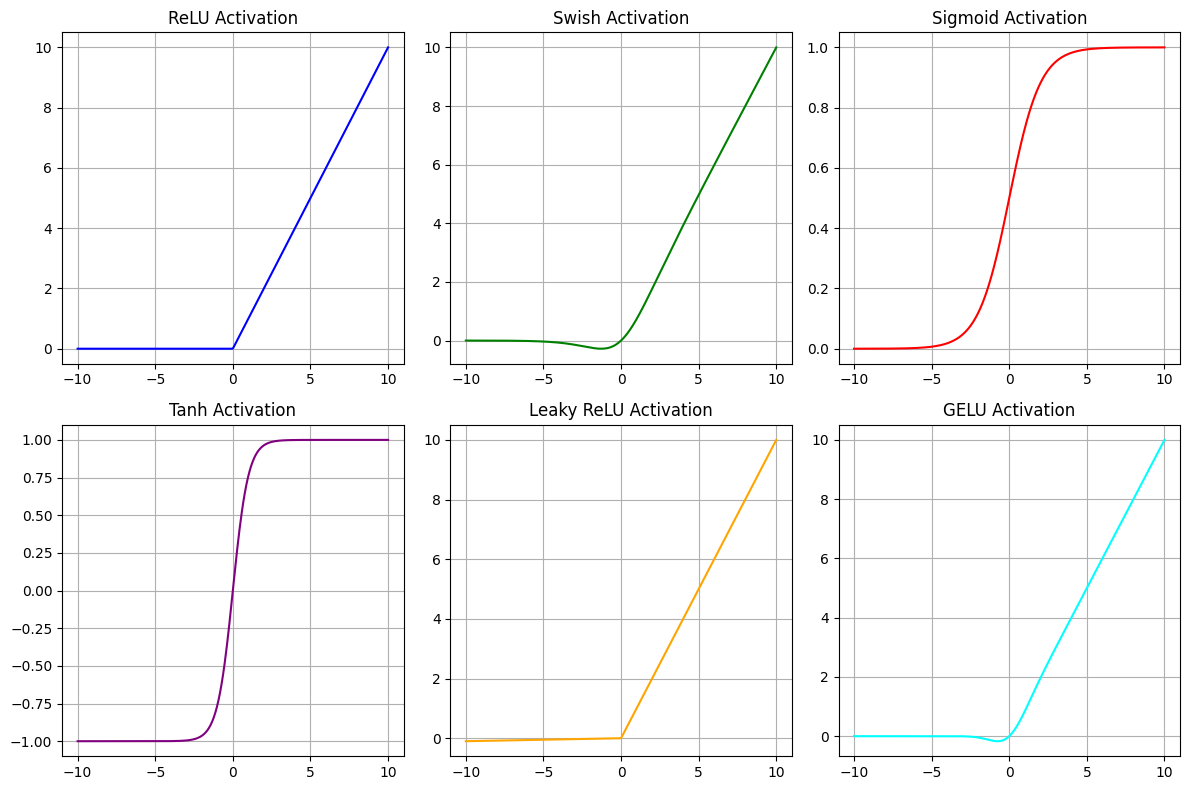

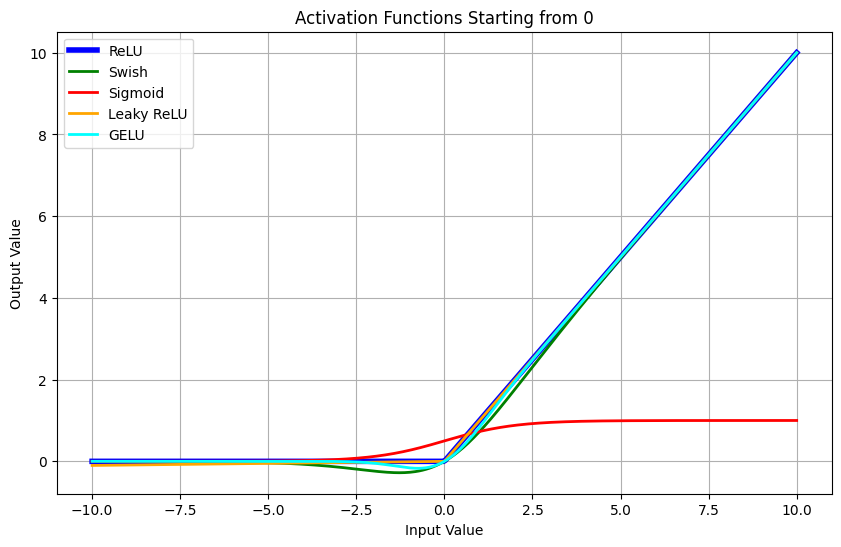

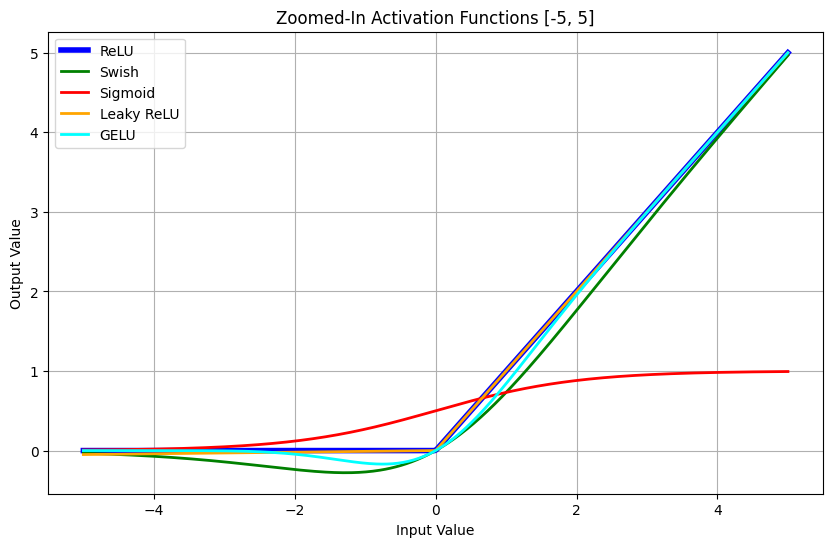

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define different activation functions

# ReLU Activation
def relu(x):
    return np.maximum(0, x)

# Swish Activation
def swish(x):
    return x * (1 / (1 + np.exp(-x)))

# Sigmoid Activation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Tanh Activation
def tanh(x):
    return np.tanh(x)

# Leaky ReLU Activation
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

# GELU Activation
def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * np.power(x, 3))))

# Define a range of input values
x = np.linspace(-10, 10, 400)

# Apply each activation function to the input values
relu_values = relu(x)
swish_values = swish(x)
sigmoid_values = sigmoid(x)
tanh_values = tanh(x)
leaky_relu_values = leaky_relu(x)
gelu_values = gelu(x)

# Plot individual activations
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.plot(x, relu_values, label="ReLU", color="blue")
plt.title("ReLU Activation")
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(x, swish_values, label="Swish", color="green")
plt.title("Swish Activation")
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(x, sigmoid_values, label="Sigmoid", color="red")
plt.title("Sigmoid Activation")
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(x, tanh_values, label="Tanh", color="purple")
plt.title("Tanh Activation")
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(x, leaky_relu_values, label="Leaky ReLU", color="orange")
plt.title("Leaky ReLU Activation")
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(x, gelu_values, label="GELU", color="cyan")
plt.title("GELU Activation")
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot combined graph for activation functions starting from 0
plt.figure(figsize=(10, 6))
plt.plot(x, relu_values, label="ReLU", color="blue", linewidth=4)
plt.plot(x, swish_values, label="Swish", color="green", linewidth=2)
plt.plot(x, sigmoid_values, label="Sigmoid", color="red", linewidth=2)
plt.plot(x, leaky_relu_values, label="Leaky ReLU", color="orange", linewidth=2)
plt.plot(x, gelu_values, label="GELU", color="cyan", linewidth=2)

plt.title("Activation Functions Starting from 0")
plt.xlabel("Input Value")
plt.ylabel("Output Value")
plt.grid(True)
plt.legend(loc='upper left')
plt.show()

# Zoomed-in visualization for the range [-5.0, 5.0]
# Define a narrower range of input values for zoomed-in plot
x_zoom = np.linspace(-5, 5, 400)

# Apply each activation function to the zoomed-in input values
relu_values_zoom = relu(x_zoom)
swish_values_zoom = swish(x_zoom)
sigmoid_values_zoom = sigmoid(x_zoom)
tanh_values_zoom = tanh(x_zoom)
leaky_relu_values_zoom = leaky_relu(x_zoom)
gelu_values_zoom = gelu(x_zoom)

# Plot combined graph for activation functions zoomed into [-5, 5]
plt.figure(figsize=(10, 6))
plt.plot(x_zoom, relu_values_zoom, label="ReLU", color="blue", linewidth=4)
plt.plot(x_zoom, swish_values_zoom, label="Swish", color="green", linewidth=2)
plt.plot(x_zoom, sigmoid_values_zoom, label="Sigmoid", color="red", linewidth=2)
plt.plot(x_zoom, leaky_relu_values_zoom, label="Leaky ReLU", color="orange", linewidth=2)
plt.plot(x_zoom, gelu_values_zoom, label="GELU", color="cyan", linewidth=2)

plt.title("Zoomed-In Activation Functions [-5, 5]")
plt.xlabel("Input Value")
plt.ylabel("Output Value")
plt.grid(True)
plt.legend(loc='upper left')
plt.show()


- **ReLU (Rectified Linear Unit)**: ReLU outputs zero for any negative input and passes positive input values as they are. It's simple and computationally efficient but suffers from dead neurons, where some neurons stop learning if they output zero consistently.

- **Swish (SiLU)**: Swish is a smooth, non-linear activation function that allows small negative values to pass through. It avoids the dead neuron problem and generally provides better gradient flow than ReLU, leading to improved learning in deeper networks.

- **Sigmoid**: Sigmoid maps any input to a value between 0 and 1. While useful for binary classification, it can suffer from vanishing gradients, making it less effective for deeper networks.

- **Tanh**: Similar to Sigmoid but maps inputs to the range between -1 and 1. It can mitigate the vanishing gradient problem to some extent, but still struggles with it in deeper networks.

- **Leaky ReLU**: A variant of ReLU that allows a small, non-zero gradient for negative inputs. This helps reduce the risk of dead neurons while retaining the simplicity of ReLU.

- **GELU (Gaussian Error Linear Unit)**: GELU combines the benefits of ReLU and Sigmoid, allowing smoother gradients and better performance in many cases, especially in transformer models.

## Dead Neurons
"Dead neurons" is a phenomenon particularly common in ReLU networks. It occurs when neurons output zero for all inputs, making them inactive during training. This can be a serious issue as these neurons no longer contribute to learning.

ReLU networks are prone to this problem since any input below zero produces a gradient of zero, which leads to zero weight updates. In contrast, activation functions like Swish have smoother transitions, reducing the likelihood of dead neurons.

The following sections experiment with different networks using ReLU and Swish to visualize how neuron activations behave.


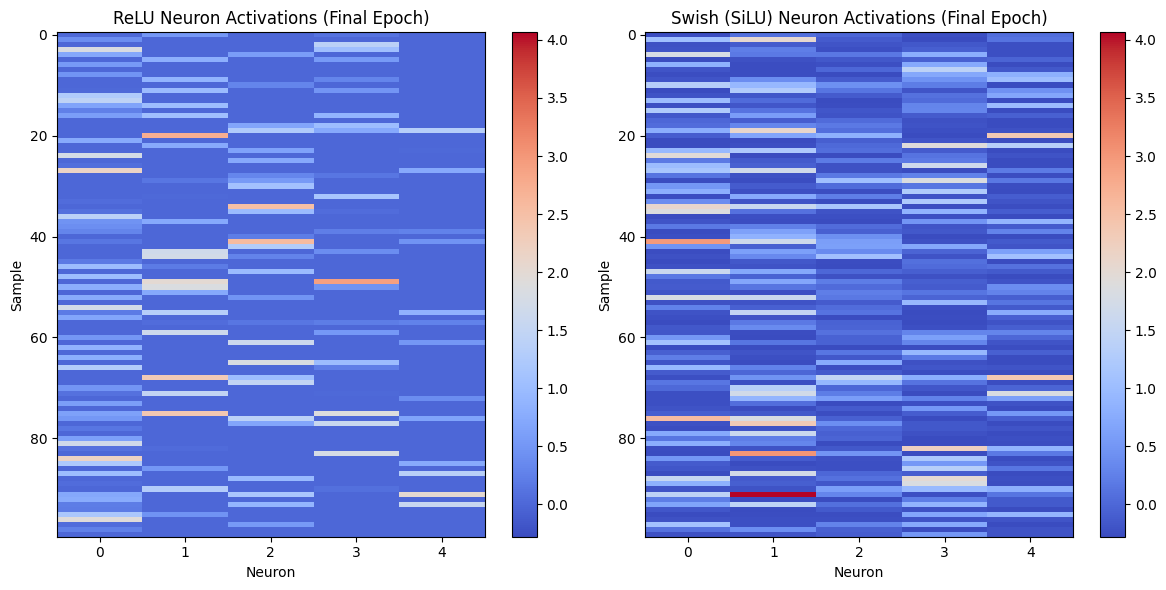

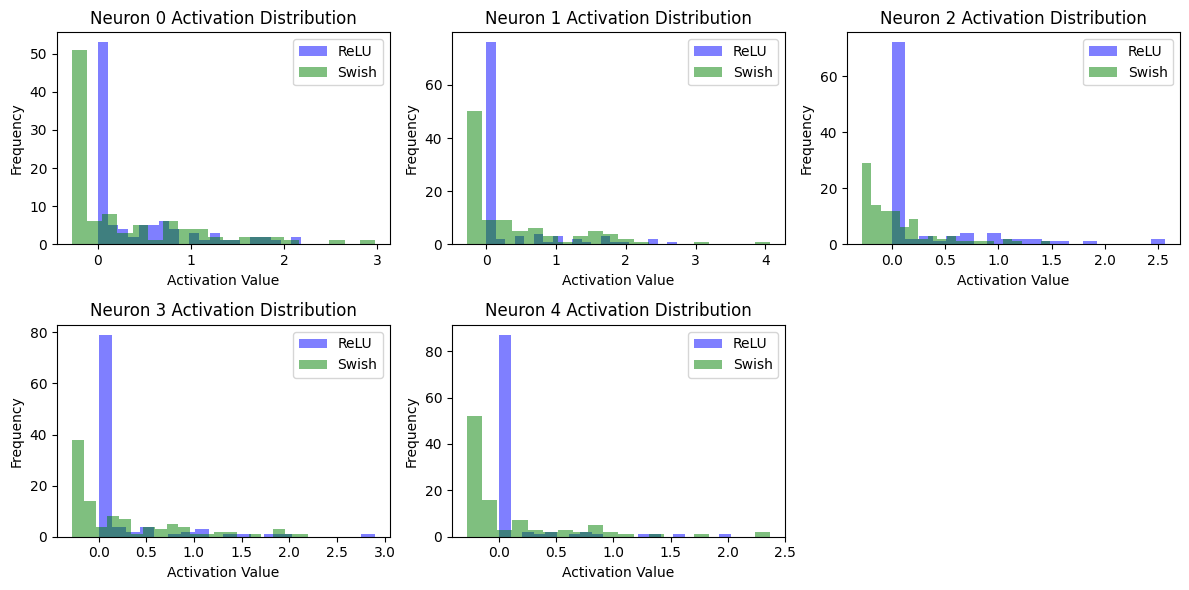

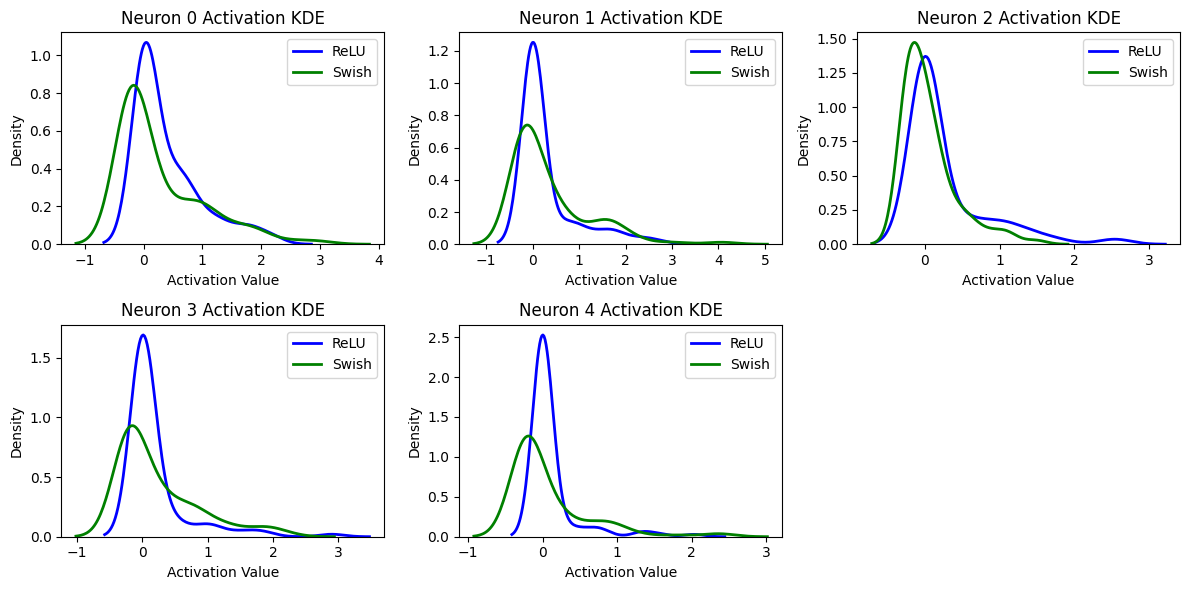

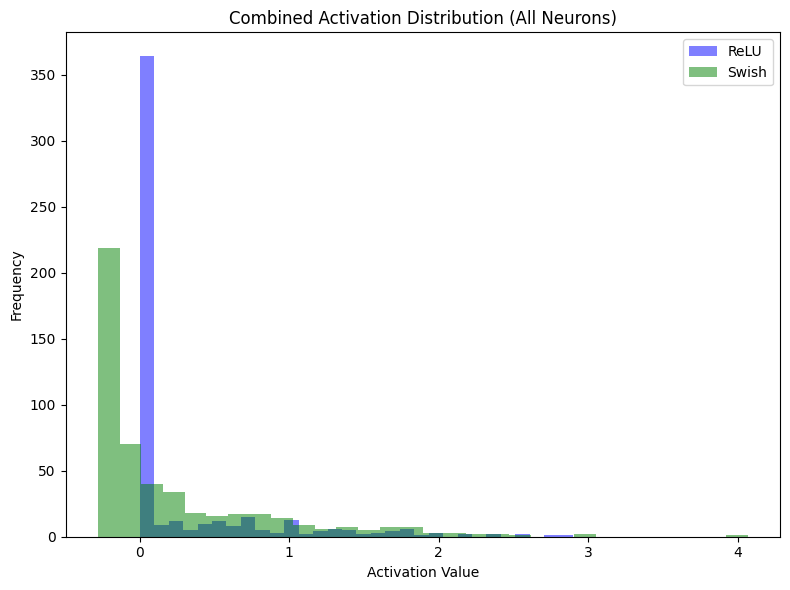

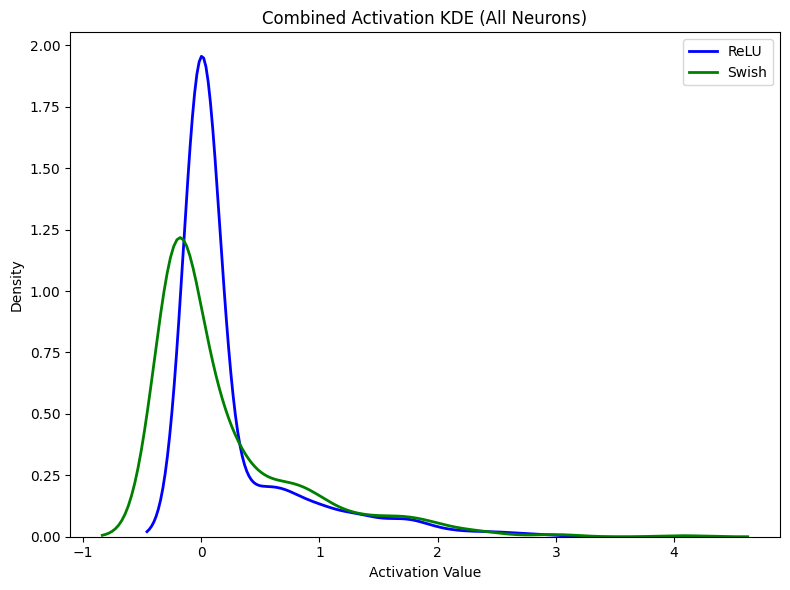

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for KDE plots
import numpy as np

# Define a simple neural network with ReLU and Swish (SiLU) activations
class SimpleNN(nn.Module):
    def __init__(self, activation_fn):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(10, 5)  # input layer
        self.activation = activation_fn  # activation function (ReLU or Swish/SiLU)
        self.fc2 = nn.Linear(5, 1)  # output layer

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

# Create two neural networks, one with ReLU and one with Swish (SiLU)
relu_net = SimpleNN(activation_fn=nn.ReLU())
swish_net = SimpleNN(activation_fn=nn.SiLU())

# Loss function and optimizer
criterion = nn.MSELoss()
relu_optimizer = optim.SGD(relu_net.parameters(), lr=0.5)  # Increased learning rate
swish_optimizer = optim.SGD(swish_net.parameters(), lr=0.5)

# Generate random input data and target
torch.manual_seed(42)  # for reproducibility
inputs = torch.randn(100, 10) * 2 - 1  # Adjusted input scaling to introduce more negative values
inputs = torch.randn(100, 10)
targets = torch.randn(100, 1)

# Function to train the network and track neuron activations
def train_network(net, optimizer, num_epochs=100):  # Increased epochs
    activation_history = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        # Track the activations after the first layer (after the activation function)
        with torch.no_grad():
            activation_after = net.activation(net.fc1(inputs))  # Apply the activation function to fc1 output
            activation_history.append(activation_after.numpy().copy())

    return activation_history

# Train both networks
relu_activations = train_network(relu_net, relu_optimizer)
swish_activations = train_network(swish_net, swish_optimizer)

# -------------------- Individual Neuron Plots --------------------

# Find the min and max activation values across both networks for consistent color scaling
vmin = min(np.min(relu_activations[-1]), np.min(swish_activations[-1]))
vmax = max(np.max(relu_activations[-1]), np.max(swish_activations[-1]))

plt.figure(figsize=(12, 6))

# Plot ReLU activations with unified color scale
plt.subplot(1, 2, 1)
plt.imshow(relu_activations[-1], aspect='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title('ReLU Neuron Activations (Final Epoch)')
plt.xlabel('Neuron')
plt.ylabel('Sample')

# Plot Swish activations with unified color scale
plt.subplot(1, 2, 2)
plt.imshow(swish_activations[-1], aspect='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title('Swish (SiLU) Neuron Activations (Final Epoch)')
plt.xlabel('Neuron')
plt.ylabel('Sample')

plt.tight_layout()
plt.show()

# Plot histograms for ReLU and Swish
plt.figure(figsize=(12, 6))
for i in range(relu_activations[-1].shape[1]):
    plt.subplot(2, 3, i+1)
    # Plot histograms
    plt.hist(relu_activations[-1][:, i], bins=20, color='blue', alpha=0.5, label='ReLU')
    plt.hist(swish_activations[-1][:, i], bins=20, color='green', alpha=0.5, label='Swish')
    plt.title(f'Neuron {i} Activation Distribution')
    plt.xlabel('Activation Value')
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()

# Plot KDE trendlines for ReLU and Swish on separate plots
plt.figure(figsize=(12, 6))
for i in range(relu_activations[-1].shape[1]):
    plt.subplot(2, 3, i+1)

    # Plot KDE trendlines
    sns.kdeplot(relu_activations[-1][:, i], color='blue', lw=2, label='ReLU')
    sns.kdeplot(swish_activations[-1][:, i], color='green', lw=2, label='Swish')

    plt.title(f'Neuron {i} Activation KDE')
    plt.xlabel('Activation Value')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

# -------------------- Combined (All Neurons) Plots --------------------

# Combine activations across all neurons for both ReLU and Swish
relu_combined = relu_activations[-1].flatten()  # Flatten across all neurons and samples
swish_combined = swish_activations[-1].flatten()

# Plot combined histogram for ReLU and Swish activations
plt.figure(figsize=(8, 6))
plt.hist(relu_combined, bins=30, color='blue', alpha=0.5, label='ReLU')
plt.hist(swish_combined, bins=30, color='green', alpha=0.5, label='Swish')
plt.title('Combined Activation Distribution (All Neurons)')
plt.xlabel('Activation Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Plot combined KDE for ReLU and Swish activations
plt.figure(figsize=(8, 6))
sns.kdeplot(relu_combined, color='blue', lw=2, label='ReLU')
sns.kdeplot(swish_combined, color='green', lw=2, label='Swish')
plt.title('Combined Activation KDE (All Neurons)')
plt.xlabel('Activation Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Activation Plots

The activation plots show how different activation functions respond to a range of inputs:

- **ReLU**: As seen in the plot, ReLU outputs zero for all negative inputs, causing many neurons to become "stuck" at zero. This is evident in the sharp cutoff at zero, where a large portion of the values remain stuck.

- **Swish and other activations**: Unlike ReLU, Swish and other functions like Tanh and GELU allow negative values to pass through, albeit at a lower scale. This results in fewer neurons getting stuck at zero, allowing for more flexible and smooth activations.

These characteristics are particularly important in preventing the dead neuron problem and ensuring smoother gradient flow during training.


## Gradient Flow in ReLU vs. Swish Networks
In this section, we analyze the gradient flow through the network layers using both ReLU and Swish activations.

We will compare the gradients for each layer and see how ReLU causes more zero gradients, while Swish maintains smoother, non-zero gradients.

This experiment will help illustrate why Swish is more effective at preventing neurons from getting stuck at zero during backpropagation.


Layer: fc1
[ReLU Gradients]
[[  0.           0.           0.           0.           0.        ]
 [ -9.611059   -10.941208   -12.271355   -13.601501   -14.93165   ]
 [  0.04639505   0.0524702    0.05854536   0.06462051   0.07069567]
 [-11.1219635  -12.661215   -14.200468   -15.739721   -17.278975  ]]
ReLU Absolute Mean Gradient: 6.632592

[Swish Gradients]
[[ -0.86079174  -0.9928374   -1.1248832   -1.2569289   -1.3889745 ]
 [-10.255327   -11.69014    -13.124952   -14.559765   -15.994577  ]
 [  0.51070905   0.5688381    0.62696725   0.6850964    0.74322546]
 [-11.506016   -13.13619    -14.766366   -16.39654    -18.026714  ]]
Swish Absolute Mean Gradient: 7.410792
Layer: fc2
[ReLU Gradients]
[[  0.           6.3942094    0.78313446  11.798275  ]
 [  0.         -13.501097    -1.6535544  -24.911547  ]
 [  0.           0.           0.           0.        ]]
ReLU Absolute Mean Gradient: 4.920151

[Swish Gradients]
[[-2.44873375e-01  6.60100508e+00  5.19565105e-01  1.26860285e+01]
 [ 5.1633167

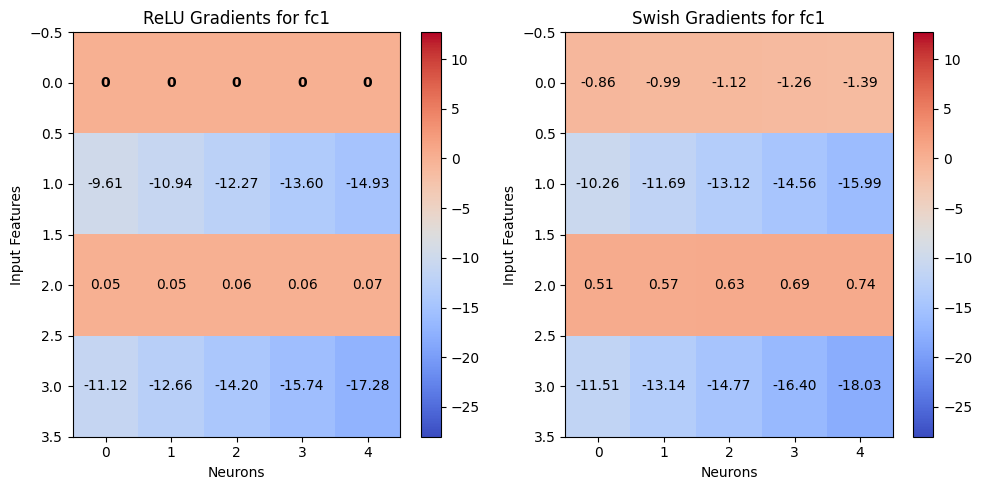

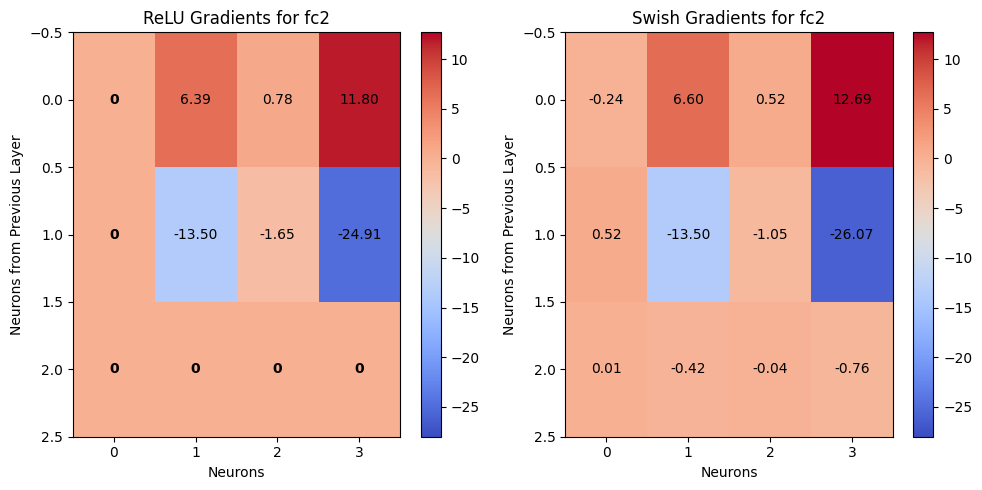

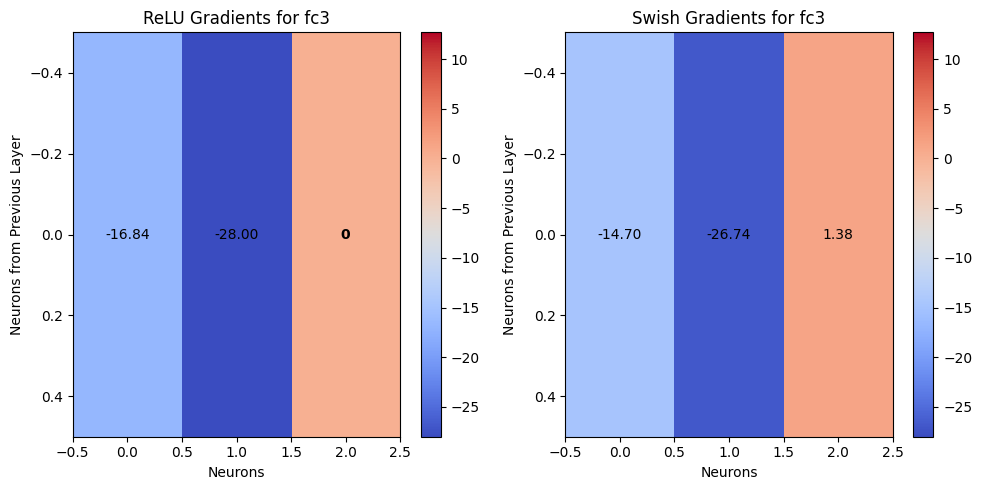

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(1)  # for reproducibility

# Define a simple neural network with ReLU and Swish (SiLU) activations
class SimpleNN(nn.Module):
    def __init__(self, activation_fn):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(5, 4)  # Input: 5 features, Output: 4 neurons
        self.fc2 = nn.Linear(4, 3)  # Hidden layer: 4 neurons, Output: 3 neurons
        self.fc3 = nn.Linear(3, 1)  # Output: 1 neuron (for simplicity)
        self.activation = activation_fn  # Activation function (ReLU or Swish/SiLU)

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x

# Create synthetic data
inputs = torch.tensor([[1.0, 2.0, 3.0, 4.0, 5.0],
                       [2.0, 3.0, 4.0, 5.0, 6.0],
                       [3.0, 4.0, 5.0, 6.0, 7.0],
                       [4.0, 5.0, 6.0, 7.0, 8.0],
                       [5.0, 6.0, 7.0, 8.0, 9.0],
                       [6.0, 7.0, 8.0, 9.0, 10.0],
                       [7.0, 8.0, 9.0, 10.0, 11.0],
                       [8.0, 9.0, 10.0, 11.0, 12.0],
                       [9.0, 10.0, 11.0, 12.0, 13.0],
                       [10.0, 11.0, 12.0, 13.0, 14.0]])

# Target values
targets = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0], [7.0], [8.0], [9.0], [10.0]])

# Create two networks with identical weights: one with ReLU and one with Swish (SiLU)
relu_net = SimpleNN(activation_fn=nn.ReLU())
swish_net = SimpleNN(activation_fn=nn.SiLU())

# Initialize Swish net to have the same weights as ReLU net
swish_net.load_state_dict(relu_net.state_dict())

# Define loss function
criterion = nn.MSELoss()

# Function to compute gradients for both networks
def compute_gradients(net, inputs, targets):
    optimizer = optim.SGD(net.parameters(), lr=0.01)
    optimizer.zero_grad()

    # Forward pass
    outputs = net(inputs)

    # Compute loss
    loss = criterion(outputs, targets)

    # Backward pass (compute gradients)
    loss.backward()

    # Collect gradients for each layer
    gradients = {
        "fc1": net.fc1.weight.grad.clone().detach().numpy(),
        "fc2": net.fc2.weight.grad.clone().detach().numpy(),
        "fc3": net.fc3.weight.grad.clone().detach().numpy()
    }

    return gradients

# Compute gradients for both ReLU and Swish networks
relu_gradients = compute_gradients(relu_net, inputs, targets)
swish_gradients = compute_gradients(swish_net, inputs, targets)

# Flatten all gradient matrices and concatenate for global min/max calculation
all_grads = np.concatenate([relu_gradients["fc1"].flatten(), relu_gradients["fc2"].flatten(), relu_gradients["fc3"].flatten(),
                            swish_gradients["fc1"].flatten(), swish_gradients["fc2"].flatten(), swish_gradients["fc3"].flatten()])
vmin, vmax = np.min(all_grads), np.max(all_grads)

# Display gradients for each layer
def display_gradients(layer, relu_grads, swish_grads):
    relu_abs_mean = np.mean(np.abs(relu_grads))
    swish_abs_mean = np.mean(np.abs(swish_grads))

    print(f"Layer: {layer}")
    print("[ReLU Gradients]")
    print(relu_grads)
    print(f"ReLU Absolute Mean Gradient: {relu_abs_mean:.6f}")
    print()

    print("[Swish Gradients]")
    print(swish_grads)
    print(f"Swish Absolute Mean Gradient: {swish_abs_mean:.6f}")
    print("=" * 40)

# Display gradients for each layer
for layer in relu_gradients.keys():
    display_gradients(layer, relu_gradients[layer], swish_gradients[layer])

# Visualization with '0' value bold and other values formatted to two decimal places
def plot_gradients(relu_grads, swish_grads, layer_name, vmin, vmax):
    plt.figure(figsize=(10, 5))

    # Plot ReLU Gradients
    plt.subplot(1, 2, 1)
    plt.title(f"ReLU Gradients for {layer_name}")
    im1 = plt.imshow(relu_grads, cmap='coolwarm', aspect='auto', vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.xlabel("Neurons")
    plt.ylabel("Input Features" if layer_name == "fc1" else "Neurons from Previous Layer")

    # Label the values in the matrix
    for i in range(relu_grads.shape[0]):
        for j in range(relu_grads.shape[1]):
            value = relu_grads[i, j]
            if value == 0:
                plt.text(j, i, '0', ha='center', va='center', color='black', fontweight='bold')
            else:
                plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')

    # Plot Swish Gradients
    plt.subplot(1, 2, 2)
    plt.title(f"Swish Gradients for {layer_name}")
    im2 = plt.imshow(swish_grads, cmap='coolwarm', aspect='auto', vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.xlabel("Neurons")
    plt.ylabel("Input Features" if layer_name == "fc1" else "Neurons from Previous Layer")

    # Label the values in the matrix
    for i in range(swish_grads.shape[0]):
        for j in range(swish_grads.shape[1]):
            value = swish_grads[i, j]
            if value == 0:
                plt.text(j, i, '0', ha='center', va='center', color='black', fontweight='bold')
            else:
                plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')

    plt.tight_layout()
    plt.show()

# Plot the gradients for each layer with consistent color scale and zero-labeling
for layer in relu_gradients.keys():
    plot_gradients(relu_gradients[layer], swish_gradients[layer], layer, vmin, vmax)


### Experimental Analysis
 The gradient visualization shows several key findings:
 - ReLU exhibits a significant number of zero gradients, indicating dead neurons and hindered learning.
 - Swish, by comparison, has far fewer zero gradients, enabling more consistent learning across all neurons.

 The figures display gradients for each layer. Zero values are bolded, and non-zero values are displayed to two decimal places.

 These results confirm that Swish helps alleviate the problem of zero gradients and stuck neurons, improving gradient flow and learning stability.


## Conclusion

In this notebook, we explored the characteristics of different activation functions and observed the impact of ReLU and Swish on neuron activations and gradient flow. Through the visualizations, it is clear that Swish provides a more stable gradient flow, reducing the risk of dead neurons and improving the overall learning process in neural networks.